# check for the extreme values that are in Sentinel-3



In [7]:
# import modules
import pandas as pd
import geopandas as gpd
import numpy as np
import shapely as shp
import xarray as xr
import rasterio
import matplotlib.pyplot as plt
import cartopy
import glob
import os
import re
import rioxarray as rio

In [8]:
# get from the data folder all the lakes and months that exist
files = sorted(glob.glob("data/*.nc"))

lake_files = {}

pattern = re.compile(r"S3_LST_L2_(.+)_(\d{4})_(\d{2})\.nc$")

for file in files:
    filename = os.path.basename(file)

    match = pattern.match(filename)

    if match is None:
        print(f"Could not parse filename: {filename}")
        continue

    lake_id = match.group(1)

    lake_files.setdefault(lake_id, []).append(file)


print("Lakes found:")
for lake_id, files_for_lake in lake_files.items():
    print(f"{lake_id}: {len(files_for_lake)} files")

Could not parse filename: openEO.nc
Lakes found:
lake_1: 116 files
lake_2: 9 files
lake_3: 116 files
lake_4: 117 files
lake_7: 116 files
lake_8: 117 files
lake_9: 116 files


In [10]:
# ============================================================
# ONE LAKE: calculate mean LST + select hot/cold scenes
# + plot actual LST scenes with lake and 500 m buffer
# ============================================================

import numpy as np
import pandas as pd
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt


# ============================================================
# 1. Select one lake
# ============================================================

lake_file_key = list(lake_files.keys())[-1]   # e.g. lake_2
print("Processing:", lake_file_key)

lake_file_dirs = lake_files[lake_file_key]


# ============================================================
# 2. Open and concatenate all NetCDF files
# ============================================================

datasets=  []

for file in lake_file_dirs:
    ds = xr.open_dataset(file, engine="netcdf4")
    datasets.append(ds)

data = xr.concat(datasets, dim="t")

# Make xarray spatially aware
data = data.rio.write_crs("EPSG:4326")
data = data.rio.set_spatial_dims(x_dim="x", y_dim="y")

# IMPORTANT:
# Keep the original/full scenes for visualization later
data_full = data




Processing: lake_9


<positron-console-cell-10>:33: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.


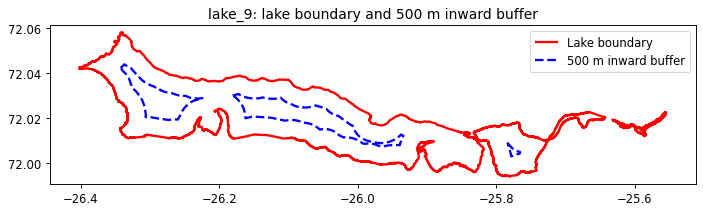

In [11]:
# ============================================================
# 3. Load lake polygon
# ============================================================

lake_id = lake_file_key

lakes = gpd.read_file(
    r"../lake_polygons/largest_lakes_num_pixels.geojson"
)

lakes["lake_id"] = "lake_" + lakes["lake_id"].astype(str)

lake = lakes[lakes["lake_id"] == lake_id]


# ============================================================
# 4. Create 500 m inward buffer
# ============================================================

# Reproject to a CRS in metres
lake_5938 = lake.to_crs(5938)

# Shrink inward by 500 m
lake_5938_buffered = lake_5938.geometry.buffer(-900)

# Back to WGS84
lake_buffered = lake_5938_buffered.to_crs(4326)

lake = lake.to_crs(epsg = 4326)

# Quick check of lake and buffer
fig, ax = plt.subplots(figsize=(10, 3))

lake.geometry.boundary.plot(
    ax=ax,
    color="red",
    linewidth=2,
    label="Lake boundary"
)

lake_buffered.boundary.plot(
    ax=ax,
    color="blue",
    linewidth=2,
    linestyle="--",
    label="500 m inward buffer"
)

ax.legend()
ax.set_title(f"{lake_id}: lake boundary and 500 m inward buffer")

plt.show()



C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



HIGH TEMPERATURE SCENES (> 8 °C)
                     lst_mean_C  lst_median_C   lst_std  n_valid_pixels
datetime                                                               
2017-06-13 14:23:00   38.662695     38.733011  0.814826              26
2017-06-14 13:57:00   31.136213     31.087000  1.317683              28
2019-09-24 22:13:00   31.093988     31.093988  0.000000               1
2017-06-13 21:07:00   30.822465     30.947992  0.758015              30
2017-06-13 19:26:00   30.743333     31.342004  1.403917              27
...                         ...           ...       ...             ...
2021-08-17 12:46:00    8.037996      8.309991  0.471110               4
2021-07-16 23:49:00    8.029106      7.984003  2.290024              18
2023-07-29 14:29:00    8.021266      8.379999  1.067842              30
2021-08-02 20:50:00    8.011935      7.794992  1.031502              30
2019-08-04 23:07:00    8.000137      7.700006  1.382921              29

[309 rows x 4 columns]

LOW T

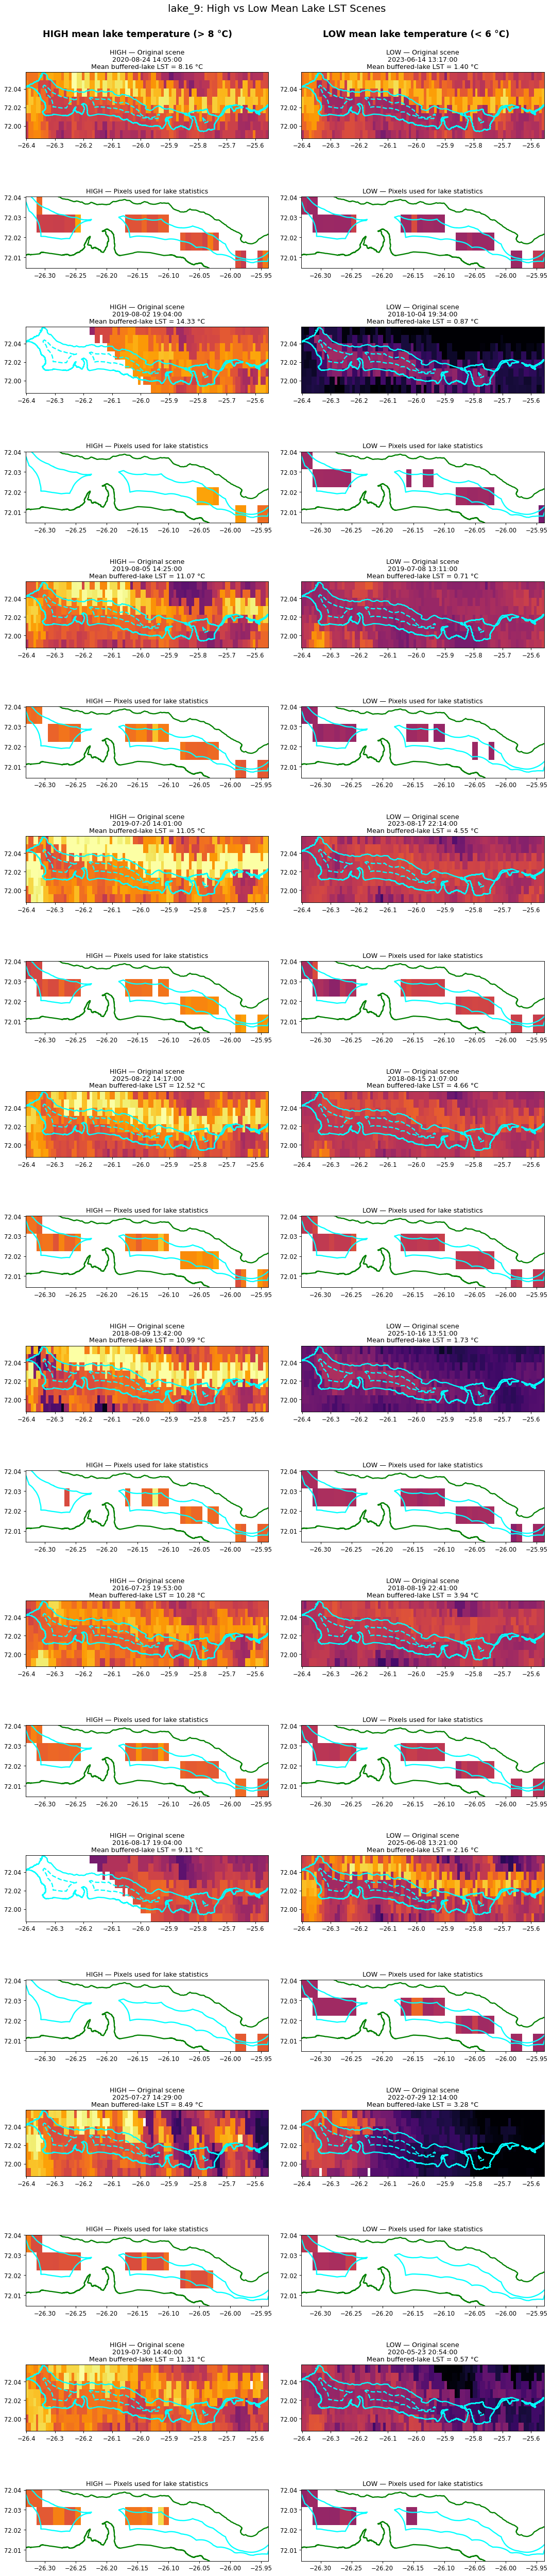

In [12]:
# ============================================================
# 5. Clip data to buffered lake
# ============================================================

data = data_full.rio.clip(
    lake_buffered.geometry,
    lake_buffered.crs,
    drop=True
)


# ============================================================
# 6. Cloud filtering
# ============================================================

cloudy = data["confidence_in"] >= 2**14

data["LST_c_filtered"] = data["LST"].where(~cloudy)

data["LST_uncertainty_c_filtered"] = (
    data["LST_uncertainty"].where(~cloudy)
)


# ============================================================
# 7. Calculate statistics for every scene
# ============================================================

# Number of valid pixels
counts_per_timestep = (
    data["LST_c_filtered"]
    .count(dim=("x", "y"))
)

# Mean LST in Celsius
mean = (
    data["LST_c_filtered"]
    .mean(("x", "y"))
    - 273.15
)

# Median LST in Celsius
median = (
    data["LST_c_filtered"]
    .median(("x", "y"))
    - 273.15
)

# Mean uncertainty
uncertainty = (
    data["LST_uncertainty_c_filtered"]
    .mean(("x", "y"))
)

# Standard deviation
std = (
    data["LST_c_filtered"]
    .std(("x", "y"))
)


# ============================================================
# 8. Make proper datetime coordinate
# ============================================================

data["t"] = pd.to_datetime(data["t"].values)


# ============================================================
# 9. Store results in pandas DataFrame
# ============================================================

results_S3 = pd.DataFrame({
    "datetime": pd.to_datetime(median.t.values),
    "lst_median_C": median.values,
    "lst_mean_C": mean.values,
    "lst_mean_uncertainty": uncertainty.values,
    "lst_std": std.values,
    "n_valid_pixels": counts_per_timestep.values,
})

results_S3 = results_S3.set_index("datetime")


# ============================================================
# 10. Select hot and cold scenes
# ============================================================

# HIGH = mean lake temperature > 8 °C
high_scenes = (
    results_S3[
        results_S3["lst_mean_C"] > 8
    ]
    .sort_values("lst_mean_C", ascending=False)
)

# LOW = mean lake temperature < 6 °C
low_scenes = (
    results_S3[
        (results_S3["lst_mean_C"] < 6) & (results_S3["lst_mean_C"] > 0)
    ]
    .sort_values("lst_mean_C", ascending=True)
)

print("\n========================================")
print("HIGH TEMPERATURE SCENES (> 8 °C)")
print("========================================")

print(
    high_scenes[
        ["lst_mean_C", "lst_median_C", "lst_std", "n_valid_pixels"]
    ]
)

print("\n========================================")
print("LOW TEMPERATURE SCENES (< 6 °C)")
print("========================================")

print(
    low_scenes[
        ["lst_mean_C", "lst_median_C", "lst_std", "n_valid_pixels"]
    ]
)


# ============================================================
# 11. Choose how many scenes to display
# ============================================================

n_scenes = 10

# Randomly select 10 HIGH scenes (> 8 °C)
high_to_plot = high_scenes.sample(
    n=min(n_scenes, len(high_scenes)),
    random_state=42
)

# Randomly select 10 LOW scenes (< 6 °C)
low_to_plot = low_scenes.sample(
    n=min(n_scenes, len(low_scenes)),
    random_state=42
)


# ============================================================
# 12. Print selected scenes
# ============================================================

print("\n========================================")
print("SELECTED HIGH SCENES")
print("========================================")

for dt, row in high_to_plot.iterrows():
    print(
        dt,
        f"| mean = {row['lst_mean_C']:.2f} °C"
    )


print("\n========================================")
print("SELECTED LOW SCENES")
print("========================================")

for dt, row in low_to_plot.iterrows():
    print(
        dt,
        f"| mean = {row['lst_mean_C']:.2f} °C"
    )


# ============================================================
# 13. Determine common colour scale
# ============================================================
#
# IMPORTANT:
# The same colour scale is used for all images so that
# temperatures can actually be compared between scenes.
# ============================================================

all_scene_values = []

selected_datetimes = list(high_to_plot.index) + list(low_to_plot.index)

for dt in selected_datetimes:

    scene = data_full["LST"].sel(t=dt) - 273.15

    values = scene.values

    values = values[np.isfinite(values)]

    if len(values) > 0:
        all_scene_values.extend(values)


if len(all_scene_values) > 0:

    vmin = np.nanpercentile(all_scene_values, 2)
    vmax = np.nanpercentile(all_scene_values, 98)

else:

    vmin = 0
    vmax = 15


print("\nColour scale:")
print(f"vmin = {vmin:.2f} °C")
print(f"vmax = {vmax:.2f} °C")


# ============================================================
# 14. Plot high vs low scenes
# ============================================================
#
# For every selected scene:
#
#   TOP    = original/full LST scene
#            + lake boundary
#            + 500 m inward buffer
#
#   BOTTOM = LST pixels actually used for the statistics
#            (= buffered lake + cloud filtered)
#
# HIGH scenes are on the LEFT
# LOW scenes are on the RIGHT
# ============================================================

nrows = max(
    len(high_to_plot),
    len(low_to_plot)
)

# Two columns (HIGH / LOW)
# Two panels per scene (original / selected pixels)
fig, axes = plt.subplots(
    nrows=nrows * 2,
    ncols=2,
    figsize=(13, 6 * nrows),
    squeeze=False
)


# ============================================================
# Function for plotting one scene
# ============================================================

def plot_scene(
    ax_original,
    ax_clipped,
    datetime,
    mean_temp,
    label
):

    # ========================================================
    # A. ORIGINAL / FULL SCENE
    # ========================================================

    scene_full = (
        data_full["LST"]
        .sel(t=datetime)
        - 273.15
    )

    im = scene_full.plot(
        ax=ax_original,
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # Lake boundary
    lake.boundary.plot(
        ax=ax_original,
        color="cyan",
        linewidth=2
    )

    # 500 m inward buffer
    lake_buffered.boundary.plot(
        ax=ax_original,
        color="cyan",
        linewidth=2,
        linestyle="--"
    )

    ax_original.set_title(
        f"{label} — Original scene\n"
        f"{pd.Timestamp(datetime).strftime('%Y-%m-%d %H:%M:%S')}\n"
        f"Mean buffered-lake LST = {mean_temp:.2f} °C",
        fontsize=11
    )

    ax_original.set_xlabel("")
    ax_original.set_ylabel("")


    # ========================================================
    # B. BUFFERED + CLOUD-FILTERED PIXELS
    # ========================================================

    # This is the data that was actually used to calculate
    # the mean/median/std above.
    #
    # data has already been:
    #   1. clipped to the 500 m inward buffer
    #   2. cloud filtered
    #
    scene_clipped = (
        data["LST_c_filtered"]
        .sel(t=datetime)
        - 273.15
    )

    scene_clipped.plot(
        ax=ax_clipped,
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    # Plot the lake boundary
    lake.boundary.plot(
        ax=ax_clipped,
        color="green",
        linewidth=2
    )

    # Plot the buffered boundary
    lake_buffered.boundary.plot(
        ax=ax_clipped,
        color="cyan",
        linewidth=2
    )

    ax_clipped.set_title(
        f"{label} — Pixels used for lake statistics",
        fontsize=11
    )

    ax_clipped.set_xlabel("")
    ax_clipped.set_ylabel("")


    return im


# ============================================================
# 15. Plot HIGH scenes on LEFT
# ============================================================

for i, (datetime, values) in enumerate(
    high_to_plot.iterrows()
):

    # Two rows per scene
    row_original = i * 2
    row_clipped = i * 2 + 1

    plot_scene(
        axes[row_original, 0],
        axes[row_clipped, 0],
        datetime,
        values["lst_mean_C"],
        "HIGH"
    )


# ============================================================
# 16. Plot LOW scenes on RIGHT
# ============================================================

for i, (datetime, values) in enumerate(
    low_to_plot.iterrows()
):

    # Two rows per scene
    row_original = i * 2
    row_clipped = i * 2 + 1

    plot_scene(
        axes[row_original, 1],
        axes[row_clipped, 1],
        datetime,
        values["lst_mean_C"],
        "LOW"
    )


# ============================================================
# 17. Turn off unused HIGH panels
# ============================================================

for i in range(
    len(high_to_plot),
    nrows
):

    axes[i * 2, 0].axis("off")
    axes[i * 2 + 1, 0].axis("off")


# ============================================================
# 18. Turn off unused LOW panels
# ============================================================

for i in range(
    len(low_to_plot),
    nrows
):

    axes[i * 2, 1].axis("off")
    axes[i * 2 + 1, 1].axis("off")


# ============================================================
# 19. Column labels
# ============================================================

fig.text(
    0.25,
    0.995,
    "HIGH mean lake temperature (> 8 °C)",
    ha="center",
    va="top",
    fontsize=15,
    fontweight="bold"
)

fig.text(
    0.75,
    0.995,
    "LOW mean lake temperature (< 6 °C)",
    ha="center",
    va="top",
    fontsize=15,
    fontweight="bold"
)


# ============================================================
# 20. Common colourbar
# ============================================================

last_im = None

for ax in axes.flat:

    if len(ax.images) > 0:

        last_im = ax.images[0]
        break


if last_im is not None:

    cbar = fig.colorbar(
        last_im,
        ax=axes,
        orientation="vertical",
        fraction=0.015,
        pad=0.02
    )

    cbar.set_label(
        "Land Surface Temperature (°C)"
    )


# ============================================================
# 21. Overall title
# ============================================================

fig.suptitle(
    f"{lake_id}: High vs Low Mean Lake LST Scenes",
    fontsize=17,
    y=1.005
)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# 5. Clip data to buffered lake
# ============================================================

data = data_full.rio.clip(
    lake_buffered.geometry,
    lake_buffered.crs,
    drop=True
)


# ============================================================
# 6. Cloud filtering
# ============================================================

cloudy = data["confidence_in"] >= 2**14

data["LST_c_filtered"] = data["LST"].where(~cloudy)

data["LST_uncertainty_c_filtered"] = (
    data["LST_uncertainty"].where(~cloudy)
)


# ============================================================
# 7. Calculate statistics for every scene
# ============================================================

# Number of valid pixels
counts_per_timestep = (
    data["LST_c_filtered"]
    .count(dim=("x", "y"))
)

# Mean LST in Celsius
mean = (
    data["LST_c_filtered"]
    .mean(("x", "y"))
    - 273.15
)

# Median LST in Celsius
median = (
    data["LST_c_filtered"]
    .median(("x", "y"))
    - 273.15
)

# Mean uncertainty
uncertainty = (
    data["LST_uncertainty_c_filtered"]
    .mean(("x", "y"))
)

# Standard deviation
std = (
    data["LST_c_filtered"]
    .std(("x", "y"))
)


# ============================================================
# 8. Make proper datetime coordinate
# ============================================================

data["t"] = pd.to_datetime(data["t"].values)


# ============================================================
# 9. Store results in pandas DataFrame
# ============================================================

results_S3 = pd.DataFrame({
    "datetime": pd.to_datetime(median.t.values),
    "lst_median_C": median.values,
    "lst_mean_C": mean.values,
    "lst_mean_uncertainty": uncertainty.values,
    "lst_std": std.values,
    "n_valid_pixels": counts_per_timestep.values,
})

results_S3 = results_S3.set_index("datetime")


# ============================================================
# 10. Select hot and cold scenes
# ============================================================

# HIGH = mean lake temperature > 8 °C
high_scenes = (
    results_S3[
        results_S3["lst_mean_C"] > 8
    ]
    .sort_values("lst_mean_C", ascending=False)
)

# LOW = mean lake temperature < 6 °C
low_scenes = (
    results_S3[
        (results_S3["lst_mean_C"] < 6) & (results_S3["lst_mean_C"] > 0)
    ]
    .sort_values("lst_mean_C", ascending=True)
)

print("\n========================================")
print("HIGH TEMPERATURE SCENES (> 8 °C)")
print("========================================")

print(
    high_scenes[
        ["lst_mean_C", "lst_median_C", "lst_std", "n_valid_pixels"]
    ]
)

print("\n========================================")
print("LOW TEMPERATURE SCENES (< 6 °C)")
print("========================================")

print(
    low_scenes[
        ["lst_mean_C", "lst_median_C", "lst_std", "n_valid_pixels"]
    ]
)


# ============================================================
# ============================================================
# 11. Choose how many scenes to display
# ============================================================

# Six scenes total: 3 HIGH + 3 LOW.
n_scenes_per_group = 3

high_to_plot = high_scenes.sample(
    n=min(n_scenes_per_group, len(high_scenes)),
    random_state=42
)

low_to_plot = low_scenes.sample(
    n=min(n_scenes_per_group, len(low_scenes)),
    random_state=42
)


# ============================================================
# 12. Print selected scenes
# ============================================================

print("\n========================================")
print("SELECTED HIGH SCENES")
print("========================================")

for dt, row in high_to_plot.iterrows():
    print(
        dt,
        f"| mean = {row['lst_mean_C']:.2f} °C"
    )

print("\n========================================")
print("SELECTED LOW SCENES")
print("========================================")

for dt, row in low_to_plot.iterrows():
    print(
        dt,
        f"| mean = {row['lst_mean_C']:.2f} °C"
    )


# ============================================================
# 13. Determine common colour scale
# ============================================================
#
# The same colour scale is used for every image in the PDF.
# This makes temperatures directly comparable between scenes.
# ============================================================

all_scene_values = []

selected_datetimes = list(high_to_plot.index) + list(low_to_plot.index)

for dt in selected_datetimes:

    scene = data_full["LST"].sel(t=dt) - 273.15

    values = scene.values
    values = values[np.isfinite(values)]

    if len(values) > 0:
        all_scene_values.extend(values)


if len(all_scene_values) > 0:

    vmin = np.nanpercentile(all_scene_values, 2)
    vmax = np.nanpercentile(all_scene_values, 98)

else:

    vmin = 0
    vmax = 15


print("\nColour scale:")
print(f"vmin = {vmin:.2f} °C")
print(f"vmax = {vmax:.2f} °C")


# ============================================================
# 14. Plot one scene
# ============================================================

def plot_scene(
    ax_original,
    ax_clipped,
    datetime,
    mean_temp,
    label
):
    """
    Plot one scene using two vertically stacked panels:

        TOP    = original/full LST scene
        BOTTOM = buffered + cloud-filtered pixels

    No individual colourbars are added here. A single colourbar
    is added to the whole figure below.
    """

    # --------------------------------------------------------
    # A. ORIGINAL / FULL SCENE
    # --------------------------------------------------------

    scene_full = (
        data_full["LST"]
        .sel(t=datetime)
        - 273.15
    )

    im = scene_full.plot(
        ax=ax_original,
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    lake.boundary.plot(
        ax=ax_original,
        color="cyan",
        linewidth=1.5
    )

    lake_buffered.boundary.plot(
        ax=ax_original,
        color="cyan",
        linewidth=1.5,
        linestyle="--"
    )

    ax_original.set_title(
        f"{label} — Original\n"
        f"{pd.Timestamp(datetime).strftime('%Y-%m-%d %H:%M:%S')}\n"
        f"Mean buffered-lake LST = {mean_temp:.2f} °C",
        fontsize=9
    )

    ax_original.set_xlabel("")
    ax_original.set_ylabel("")


    # --------------------------------------------------------
    # B. BUFFERED + CLOUD-FILTERED PIXELS
    # --------------------------------------------------------

    scene_clipped = (
        data["LST_c_filtered"]
        .sel(t=datetime)
        - 273.15
    )

    scene_clipped.plot(
        ax=ax_clipped,
        cmap="inferno",
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )

    lake.boundary.plot(
        ax=ax_clipped,
        color="green",
        linewidth=1.5
    )

    lake_buffered.boundary.plot(
        ax=ax_clipped,
        color="cyan",
        linewidth=1.5
    )

    ax_clipped.set_title(
        f"{label} — Pixels used for lake statistics",
        fontsize=9
    )

    ax_clipped.set_xlabel("")
    ax_clipped.set_ylabel("")

    return im


# ============================================================
# 15. Build the six-scene list
# ============================================================

scenes_to_plot = []

for datetime, values in high_to_plot.iterrows():
    scenes_to_plot.append(
        (
            datetime,
            values["lst_mean_C"],
            "HIGH"
        )
    )

for datetime, values in low_to_plot.iterrows():
    scenes_to_plot.append(
        (
            datetime,
            values["lst_mean_C"],
            "LOW"
        )
    )


# ============================================================
# 16. Write six scenes to one PDF
# ============================================================
#
# Each scene has two vertically stacked images.
# The vertical gap between those two images is deliberately small.
#
# One colourbar is shared by ALL scenes in the PDF.
# ============================================================

from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

plots_dir = Path("../plots")
plots_dir.mkdir(parents=True, exist_ok=True)

pdf_path = plots_dir / f"{lake_id}_six_scenes.pdf"

# Limit to six scenes for the requested PDF.
scenes_to_plot = scenes_to_plot[:6]

if len(scenes_to_plot) == 0:
    raise ValueError("No scenes available to plot.")

n_scene_rows = 2
n_scene_cols = 3

with PdfPages(pdf_path) as pdf:

    fig = plt.figure(
        figsize=(15, 9.5)
    )

    # Outer grid: 2 rows x 3 columns = 6 scenes.
    outer = fig.add_gridspec(
        nrows=n_scene_rows,
        ncols=n_scene_cols,
        left=0.04,
        right=0.91,
        bottom=0.07,
        top=0.91,
        wspace=0.06,
        hspace=0.16
    )

    all_axes = []
    plot_axes = []

    for scene_number, (datetime, mean_temp, label) in enumerate(
        scenes_to_plot
    ):

        outer_row = scene_number // n_scene_cols
        outer_col = scene_number % n_scene_cols

        # Two panels belonging to ONE scene.
        # Small hspace keeps them visually close together.
        inner = outer[outer_row, outer_col].subgridspec(
            nrows=2,
            ncols=1,
            hspace=0.025,
            height_ratios=[1, 1]
        )

        ax_original = fig.add_subplot(inner[0, 0])
        ax_clipped = fig.add_subplot(inner[1, 0])

        plot_scene(
            ax_original,
            ax_clipped,
            datetime,
            mean_temp,
            label
        )

        all_axes.extend([ax_original, ax_clipped])
        plot_axes.append(ax_original)

    # --------------------------------------------------------
    # One shared colourbar for every scene
    # --------------------------------------------------------

    norm = Normalize(
        vmin=vmin,
        vmax=vmax
    )

    sm = ScalarMappable(
        norm=norm,
        cmap="inferno"
    )
    sm.set_array([])

    cbar = fig.colorbar(
        sm,
        ax=all_axes,
        orientation="vertical",
        fraction=0.018,
        pad=0.015
    )

    cbar.set_label(
        "Land Surface Temperature (°C)",
        fontsize=11
    )

    # --------------------------------------------------------
    # Overall title
    # --------------------------------------------------------

    fig.suptitle(
        f"{lake_id}: High vs Low Mean Lake LST — 6 Scenes",
        fontsize=16,
        y=0.965
    )

    # Keep layout compact without letting tight_layout
    # separate the two panels belonging to a scene.
    pdf.savefig(
        fig,
        bbox_inches="tight"
    )

    plt.close(fig)

print(f"\nSaved PDF with {len(scenes_to_plot)} scenes:")
print(pdf_path)
# ============================================================
# 14. Plot 6 scenes: two maps per row + one colourbar per scene
# ============================================================
#
# Each row is one time step / scene:
#   LEFT  = original/full LST scene
#   RIGHT = buffered + cloud-filtered pixels used for statistics
#   FAR RIGHT = colourbar for that scene
#
# The colour scale is calculated separately for each scene.
# Rows are packed closely together vertically.
# ============================================================

from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

n_scenes_per_group = 3

high_to_plot = high_scenes.sample(
    n=min(n_scenes_per_group, len(high_scenes)),
    random_state=42
)

low_to_plot = low_scenes.sample(
    n=min(n_scenes_per_group, len(low_scenes)),
    random_state=42
)

selected_scenes = (
    [("HIGH", dt, row) for dt, row in high_to_plot.iterrows()]
    + [("LOW", dt, row) for dt, row in low_to_plot.iterrows()]
)


# ============================================================
# Function for plotting one scene
# ============================================================

def plot_scene(
    ax_original,
    ax_clipped,
    datetime,
    mean_temp,
    label
):
    scene_full = (
        data_full["LST"]
        .sel(t=datetime)
        - 273.15
    )

    # Calculate a colour scale independently for this date/scene
    full_values = scene_full.values
    full_values = full_values[np.isfinite(full_values)]

    if len(full_values) > 0:
        scene_vmin = np.nanpercentile(full_values, 2)
        scene_vmax = np.nanpercentile(full_values, 98)
    else:
        scene_vmin = 0
        scene_vmax = 15

    print(
        f"{pd.Timestamp(datetime):%Y-%m-%d %H:%M:%S} "
        f"colour scale: {scene_vmin:.2f}–{scene_vmax:.2f} °C"
    )

    # ========================================================
    # A. ORIGINAL / FULL SCENE
    # ========================================================

    im = scene_full.plot(
        ax=ax_original,
        cmap="inferno",
        vmin=scene_vmin,
        vmax=scene_vmax,
        add_colorbar=False
    )

    # Buffered boundary first, lake shoreline second
    lake_buffered.boundary.plot(
        ax=ax_original,
        color="cyan",
        linewidth=2,
        linestyle="--"
    )

    lake.boundary.plot(
        ax=ax_original,
        color="cyan",
        linewidth=2
    )

    ax_original.set_title(
        f"{label} — Original scene\n"
        f"{pd.Timestamp(datetime).strftime('%Y-%m-%d %H:%M:%S')}\n"
        f"Mean buffered-lake LST = {mean_temp:.2f} °C",
        fontsize=9
    )

    ax_original.set_xlabel("")
    ax_original.set_ylabel("")


    # ========================================================
    # B. PIXELS USED FOR LAKE STATISTICS
    # ========================================================

    scene_clipped = (
        data["LST_c_filtered"]
        .sel(t=datetime)
        - 273.15
    )

    scene_clipped.plot(
        ax=ax_clipped,
        cmap="inferno",
        vmin=scene_vmin,
        vmax=scene_vmax,
        add_colorbar=False
    )

    # Buffered boundary first, actual shoreline on top
    lake_buffered.boundary.plot(
        ax=ax_clipped,
        color="cyan",
        linewidth=2
    )

    lake.boundary.plot(
        ax=ax_clipped,
        color="green",
        linewidth=2
    )

    ax_clipped.set_title(
        f"{label} — Pixels used for lake statistics",
        fontsize=9
    )

    ax_clipped.set_xlabel("")
    ax_clipped.set_ylabel("")

    return im, scene_vmin, scene_vmax


# ============================================================
# Create PDF: 6 scenes, 2 maps + 1 colourbar per row
# ============================================================

output_dir = Path("plots")
output_dir.mkdir(parents=True, exist_ok=True)

pdf_path = output_dir / f"{lake_id}_six_scenes.pdf"

with PdfPages(pdf_path) as pdf:

    # 3 columns:
    #   0 = original map
    #   1 = statistics map
    #   2 = colourbar
    fig = plt.figure(
        figsize=(12, 3.25 * len(selected_scenes))
    )

    gs = fig.add_gridspec(
        nrows=len(selected_scenes),
        ncols=3,
        width_ratios=[1, 1, 0.055],
        left=0.035,
        right=0.965,
        top=0.965,
        bottom=0.025,
        wspace=0.045,
        hspace=0.055
    )

    for i, (label, datetime, values) in enumerate(selected_scenes):

        ax_original = fig.add_subplot(gs[i, 0])
        ax_clipped = fig.add_subplot(gs[i, 1])
        cax = fig.add_subplot(gs[i, 2])

        im, scene_vmin, scene_vmax = plot_scene(
            ax_original,
            ax_clipped,
            datetime,
            values["lst_mean_C"],
            label
        )

        # One colourbar specifically for this date/scene
        cbar = fig.colorbar(
            im,
            cax=cax,
            orientation="vertical"
        )

        cbar.set_label(
            "LST (°C)",
            fontsize=8
        )
        cbar.ax.tick_params(labelsize=7)

    fig.suptitle(
        f"{lake_id}: High vs Low Mean Lake LST Scenes",
        fontsize=15,
        y=0.985
    )

    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

print(f"\nSaved PDF: {pdf_path}")


C:\Users\Lenovo\anaconda3\envs\griml\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:2015: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,



HIGH TEMPERATURE SCENES (> 8 °C)
                     lst_mean_C  lst_median_C   lst_std  n_valid_pixels
datetime                                                               
2017-06-13 14:23:00   38.662695     38.733011  0.814826              26
2017-06-14 13:57:00   31.136213     31.087000  1.317683              28
2019-09-24 22:13:00   31.093988     31.093988  0.000000               1
2017-06-13 21:07:00   30.822465     30.947992  0.758015              30
2017-06-13 19:26:00   30.743333     31.342004  1.403917              27
...                         ...           ...       ...             ...
2021-08-17 12:46:00    8.037996      8.309991  0.471110               4
2021-07-16 23:49:00    8.029106      7.984003  2.290024              18
2023-07-29 14:29:00    8.021266      8.379999  1.067842              30
2021-08-02 20:50:00    8.011935      7.794992  1.031502              30
2019-08-04 23:07:00    8.000137      7.700006  1.382921              29

[309 rows x 4 columns]

LOW T